##Instalando e iniciando uma sessão Spark

In [1]:
# Install Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download and extract Spark
!wget -q http://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Install PySpark
!pip install pyspark==3.5.0

# Set environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

# Initialize SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 12.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 23.7 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425400 sha256=250276b2202c196750d4d0e4d1a86b8733102a11efaf422acd0897a46269056a
  Stored in directory: /root/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


spark.read.json() para ler um arquivo JSON

In [3]:
dados = spark.read.json("/content/drive/MyDrive/Curso_Spark/aula01/aula01/imoveis.json")

In [4]:
dados

DataFrame[ident: struct<customerID:string,source:string>, listing: struct<address:struct<city:string,location:struct<lat:double,lon:double>,neighborhood:string,zone:string>,features:struct<bathrooms:bigint,bedrooms:bigint,floors:bigint,parkingSpaces:bigint,suites:bigint,totalAreas:string,unitFloor:bigint,unitsOnTheFloor:bigint,usableAreas:string>,prices:struct<price:string,tax:struct<condo:string,iptu:string>>,types:struct<unit:string,usage:string>>]

##Vendo os dados

In [5]:
dados.show(truncate=False)

+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ident                     |listing                                                                                                                                                          |
+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{775564-BOJSMVON, Website}|{{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}, {0, 0, 0, 1, 0, 62, 0, 0, 62}, {45000, {150, 0}}, {Outros, Residencial}}                       |
|{660895-AUENKNYY, Website}|{{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}, {1, 2, 0, 1, 0, 0, 0, 0, 44}, {45000, {120, 0}}, {Apartamento, Residencial}}                |
|{751522-JESYFEQL, Website}|{{Rio de Janeiro,

In [6]:
dados.count()

73615

##Seleção de Features

In [7]:
dados.printSchema()

root
 |-- ident: struct (nullable = true)
 |    |-- customerID: string (nullable = true)
 |    |-- source: string (nullable = true)
 |-- listing: struct (nullable = true)
 |    |-- address: struct (nullable = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- location: struct (nullable = true)
 |    |    |    |-- lat: double (nullable = true)
 |    |    |    |-- lon: double (nullable = true)
 |    |    |-- neighborhood: string (nullable = true)
 |    |    |-- zone: string (nullable = true)
 |    |-- features: struct (nullable = true)
 |    |    |-- bathrooms: long (nullable = true)
 |    |    |-- bedrooms: long (nullable = true)
 |    |    |-- floors: long (nullable = true)
 |    |    |-- parkingSpaces: long (nullable = true)
 |    |    |-- suites: long (nullable = true)
 |    |    |-- totalAreas: string (nullable = true)
 |    |    |-- unitFloor: long (nullable = true)
 |    |    |-- unitsOnTheFloor: long (nullable = true)
 |    |    |-- usableAreas: string (nullable =

In [8]:
dados\
.select('ident.customerID', 'listing.*')\
.show(truncate = False)

+---------------+--------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|customerID     |address                                                                         |features                       |prices               |types                     |
+---------------+--------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|775564-BOJSMVON|{Rio de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Oeste}                 |{0, 0, 0, 1, 0, 62, 0, 0, 62}  |{45000, {150, 0}}    |{Outros, Residencial}     |
|660895-AUENKNYY|{Rio de Janeiro, {-22.869698, -43.509141}, Santíssimo, Zona Oeste}              |{1, 2, 0, 1, 0, 0, 0, 0, 44}   |{45000, {120, 0}}    |{Apartamento, Residencial}|
|751522-JESYFEQL|{Rio de Janeiro, {-22.986927, -43.646786}, Pedra de Guaratiba, Zona Oeste}      |{0

Analisando as features

In [9]:
dados\
.select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*',)\
.show(truncate = False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+------------------------+------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|totalAreas|unitFloor|unitsOnTheFloor|usableAreas|city          |location                |neighborhood            |zone        |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+------------------------+------------+-----+-----+----+
|775564-BOJSMVON|Outros     |Residencial|0        |0       |0     |1            |0     |62        |0        |0              |62         |Rio de Janeiro|{-22.909429, -43.413557}|Taquara                 |Zona Oeste  |45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1        |2       |0     |1

Tirando algumas features irrelevantes

In [10]:
dados\
.select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*',)\
.drop('city', 'location', 'totalAreas')\
.show(truncate = False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+------------------------+------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood            |zone        |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+------------------------+------------+-----+-----+----+
|775564-BOJSMVON|Outros     |Residencial|0        |0       |0     |1            |0     |0        |0              |62         |Taquara                 |Zona Oeste  |45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1        |2       |0     |1            |0     |0        |0              |44         |Santíssimo              |Zona Oeste  |45000|120  |0   |
|751522-JESYFEQL|Outros     |Residencial|0        |0       |0     |0            |0     |0 

In [11]:
dataset = dados\
.select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*',)\
.drop('city', 'location', 'totalAreas')

##Tratamento de Dados

In [12]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: string (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: string (nullable = true)
 |-- condo: string (nullable = true)
 |-- iptu: string (nullable = true)



 usableAreas, price, condo e uptu estão como String, precisamos ajustar

### Sempre que for necessário alterar a tipagem em Spark, é necessário importar os tipos, pois não são os mesmos do Python

In [13]:
from pyspark.sql.types import IntegerType, DoubleType

Usando


.withColumn


e


cast()


podemos alterar a tipagem

In [14]:
dataset\
.withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
.withColumn('price', dataset['price'].cast(DoubleType()))\
.withColumn('condo', dataset['condo'].cast(DoubleType()))\
.withColumn('iptu', dataset['iptu'].cast(DoubleType()))\
.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: double (nullable = true)
 |-- condo: double (nullable = true)
 |-- iptu: double (nullable = true)



In [15]:
dataset = dataset\
.withColumn('usableAreas', dataset['usableAreas'].cast(IntegerType()))\
.withColumn('price', dataset['price'].cast(DoubleType()))\
.withColumn('condo', dataset['condo'].cast(DoubleType()))\
.withColumn('iptu', dataset['iptu'].cast(DoubleType()))

In [16]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo|  iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|   0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|   0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|  

Para ver valores únicos de uma feature use Select com groupby, count e show

In [17]:
dataset\
.select('usage')\
.groupby('usage')\
.count()\
.show()

+-----------+-----+
|      usage|count|
+-----------+-----+
|  Comercial| 4019|
|Residencial|69596|
+-----------+-----+



Retirando os imóveis comerciais com um Select

In [18]:
dataset = dataset\
.select('*')\
.where(dataset['usage'] == 'Residencial')

In [19]:
dataset\
.select('unit')\
.groupby('unit')\
.count()\
.show()

+-----------+-----+
|       unit|count|
+-----------+-----+
|     Outros| 1190|
|Apartamento|59106|
|       Casa| 9300|
+-----------+-----+



In [20]:
dataset\
.select('zone')\
.groupby('zone')\
.count()\
.show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



## Tratando Dados faltantes

In [21]:
from pyspark.sql import functions as f

In [22]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

Esse select abaixo com count, when, isnull ou isnan e um for em toda coluna, vai identificar e somar todos os valores null e not a number

In [23]:
dataset\
.select([f.count(f.when(f.isnull(c)| f.isnan(c), True)).alias(c) for c in dataset.columns])\
.show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0| 6061|8726|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



Usando um select com na e fill preenchemos todos os valores vázios com 0

In [24]:
dataset\
.select('*')\
.na\
.fill(0)\
.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|          Santíssimo|  Zona Oeste|45000.0|120.0|  0.0|
|751522-JESYFEQL|     Outros|Residencial|        0|       0|     0|            0|     0|       

aplicando

In [25]:
dataset = dataset\
.select('*')\
.na\
.fill(0)

verificando novamente os valores nulos

In [26]:
dataset\
.select([f.count(f.when(f.isnull(c)| f.isnan(c), True)).alias(c) for c in dataset.columns])\
.show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0|    0|   0|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



contudo algumas zonas ainda estão vázias

In [27]:
dataset\
.select('zone')\
.groupby('zone')\
.count()\
.show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
|            |  157|
+------------+-----+



tratando strings vázias


pegando somente os dados diferentes do qual a zona está vázia

In [28]:
dataset = dataset\
.where(f.col('zone') != '')

In [29]:
dataset\
.select('zone')\
.groupby('zone')\
.count()\
.show()

+------------+-----+
|        zone|count|
+------------+-----+
|  Zona Norte|14379|
|  Zona Oeste|35523|
|Zona Central| 1002|
|    Zona Sul|18535|
+------------+-----+



## Preparando dados para regressão

Vamos converter a feature unit para dummy, ou seja criar uma coluna para cada categoria com 0 e 1


agrupamos pelo customer ID para garantir que está pegando todos os registros;

.pivot() cria uma coluna para valor na coluna;

.agg(f.lit(1)) está agregando o valor 1 para cada coluna criada

.na e fill para colocar 0 nas colunas não atendidas

In [30]:
dataset\
.groupby('customerID')\
.pivot('unit')\
.agg(f.lit(1))\
.na\
.fill(0)\
.show()

+---------------+-----------+----+------+
|     customerID|Apartamento|Casa|Outros|
+---------------+-----------+----+------+
|062130-QKYMWGMV|          1|   0|     0|
|630945-AEEUPRXI|          0|   1|     0|
|994985-OZQNHQKH|          1|   0|     0|
|494674-JWXRZIBM|          1|   0|     0|
|458844-UJCRFSRI|          1|   0|     0|
|155284-BRCDAOIQ|          1|   0|     0|
|396742-DUXBHLRU|          1|   0|     0|
|916072-ZJXARAXO|          1|   0|     0|
|943843-BVTWWHRQ|          1|   0|     0|
|193126-MTNIIFQN|          1|   0|     0|
|319762-UXTTQYFS|          1|   0|     0|
|931151-GZCTKADB|          1|   0|     0|
|103840-OFKPFEZJ|          0|   1|     0|
|176885-NNKZRQGM|          0|   1|     0|
|926638-PBYRAZYR|          1|   0|     0|
|744421-IZJWISWB|          1|   0|     0|
|530012-TYGLQMER|          1|   0|     0|
|209407-GTEUOVKR|          1|   0|     0|
|289667-ZPHGFHJH|          1|   0|     0|
|859388-EYTPMKER|          1|   0|     0|
+---------------+-----------+----+

In [31]:
unit = dataset\
.groupby('customerID')\
.pivot('unit')\
.agg(f.lit(1))\
.na\
.fill(0)

fazendo o mesmo para zona

In [32]:
dataset\
.groupby('customerID')\
.pivot('zone')\
.agg(f.lit(1))\
.na\
.fill(0)\
.show()

+---------------+------------+----------+----------+--------+
|     customerID|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+------------+----------+----------+--------+
|336149-TMGGYSKN|           0|         0|         1|       0|
|846345-JYHIIHQM|           0|         1|         0|       0|
|598128-VUMFFGPB|           0|         0|         0|       1|
|368553-OPCVLPHJ|           0|         1|         0|       0|
|549743-AXHKZBFK|           0|         0|         1|       0|
|812359-OJYBIPJI|           0|         0|         0|       1|
|660235-HZGMOQSM|           0|         0|         1|       0|
|060113-BUDVVMLJ|           0|         0|         1|       0|
|414450-LWZHERNQ|           0|         0|         1|       0|
|002985-MNHDTPVG|           0|         0|         1|       0|
|849580-WTTBUJKK|           0|         1|         0|       0|
|869294-GMGUYRPI|           0|         0|         1|       0|
|744421-IZJWISWB|           0|         0|         1|       0|
|046476-

In [33]:
zone = dataset\
.groupby('customerID')\
.pivot('zone')\
.agg(f.lit(1))\
.na\
.fill(0)

agora temos 2 datasets dummys e devemos juntar com o dataset principal

In [34]:
dataset\
.join(unit, 'customerID', how = 'inner')\
.join(zone, 'customerID', how = 'inner')\
.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|        neighborhood|        zone|  price|condo| iptu|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+------------+-------+-----+-----+-----------+----+------+------------+----------+----------+--------+
|775564-BOJSMVON|     Outros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|  Zona Oeste|45000.0|150.0|  0.0|          0|   0|     1|           0|         0|         1|       0|
|660

In [35]:
dataset = dataset\
.join(unit, 'customerID', how = 'inner')\
.join(zone, 'customerID', how = 'inner')

## Vetorização dos Dados

In [36]:
from pyspark.ml.feature import VectorAssembler

A biblioteca ML do Pyspark espera que as colunas sigam um padrão de nomeclatura, para isso vamos renomear elas

In [37]:
dataset = dataset.withColumnRenamed('price', 'label')

In [38]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- label: double (nullable = false)
 |-- condo: double (nullable = false)
 |-- iptu: double (nullable = false)
 |-- Apartamento: integer (nullable = true)
 |-- Casa: integer (nullable = true)
 |-- Outros: integer (nullable = true)
 |-- Zona Central: integer (nullable = true)
 |-- Zona Norte: integer (nullable = true)
 |-- Zona Oeste: integer (nullable = true)
 |-- Zona Sul: integer (nullable = true)



In [39]:
X = [
    'bathrooms',
    'bedrooms',
    'floors',
    'parkingSpaces',
    'suites',
    'unitFloor',
    'unitsOnTheFloor',
    'usableAreas',
    'condo',
    'iptu',
    'Apartamento',
    'Casa',
    'Outros',
    'Zona Central',
    'Zona Norte',
    'Zona Oeste',
    'Zona Sul'
]

passando as colunas e o nome final = features

In [40]:
assembler = VectorAssembler(inputCols = X, outputCol = 'features')

realizando as transformações

In [41]:
dataset_prep = assembler.transform(dataset).select('features', 'label')

In [42]:
dataset_prep.show(10, truncate = False)

+--------------------------------------------------------------------------+-------+
|features                                                                  |label  |
+--------------------------------------------------------------------------+-------+
|(17,[3,7,8,12,15],[1.0,62.0,150.0,1.0,1.0])                               |45000.0|
|(17,[0,1,3,7,8,10,15],[1.0,2.0,1.0,44.0,120.0,1.0,1.0])                   |45000.0|
|(17,[7,8,12,15],[132.0,100.0,1.0,1.0])                                    |50000.0|
|[2.0,3.0,3.0,1.0,1.0,2.0,4.0,60.0,400.0,120.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0]|50000.0|
|(17,[7,12,15],[200.0,1.0,1.0])                                            |50000.0|
|(17,[0,1,3,7,10,14],[1.0,1.0,1.0,33.0,1.0,1.0])                           |45336.0|
|(17,[7,12,15],[120.0,1.0,1.0])                                            |45000.0|
|(17,[7,12,15],[468.0,1.0,1.0])                                            |45000.0|
|(17,[5,7,12,15],[1.0,180.0,1.0,1.0])                            

##Exploração do dados

In [43]:
from pyspark.ml.stat import Correlation
import pandas as pd

Criando uma matriz de correlação

In [44]:
corr = Correlation.corr(dataset_prep, 'features').collect()

In [45]:
corr

[Row(pearson(features)=DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False))]

In [46]:
corr = Correlation.corr(dataset_prep, 'features').collect()[0][0]

In [47]:
corr

DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False)

In [48]:
corr.toArray()

array([[ 1.00000000e+00,  6.65910814e-01, -4.45907541e-02,
         4.87590447e-01,  7.52927830e-01,  7.62425469e-03,
        -1.07437445e-01,  5.98072790e-01,  2.00298945e-02,
         1.51023977e-02, -2.75457964e-01,  3.43042378e-01,
        -1.40183420e-01, -9.73678190e-02, -1.62497441e-01,
         2.42345124e-01, -9.87517576e-02],
       [ 6.65910814e-01,  1.00000000e+00, -8.21840063e-02,
         4.67161260e-01,  6.01199220e-01, -7.16195849e-03,
        -1.30814438e-01,  5.63750247e-01,  1.84819307e-02,
         1.36391535e-02, -2.58339018e-01,  3.49962189e-01,
        -2.05607705e-01, -1.23732152e-01, -1.11711865e-01,
         1.63821698e-01, -4.94325200e-02],
       [-4.45907541e-02, -8.21840063e-02,  1.00000000e+00,
        -4.84861921e-02, -4.81062141e-02,  1.20981700e-01,
         7.37717422e-01, -1.03916850e-01,  1.37973623e-02,
         6.68849447e-03,  1.53947015e-01, -1.42089598e-01,
        -5.19462291e-02,  1.26044467e-01, -1.69262936e-02,
        -3.17495417e-02,  1.7

In [49]:
dataframe_corr = pd.DataFrame(corr.toArray(), columns = X, index = X)

In [50]:
dataframe_corr

,bathrooms,bedrooms,floors,parkingSpaces,suites,unitFloor,unitsOnTheFloor,usableAreas,condo,iptu,Apartamento,Casa,Outros,Zona Central,Zona Norte,Zona Oeste,Zona Sul
bathrooms,1.000000,0.665911,-0.044591,0.487590,0.752928,0.007624,-0.107437,0.598073,0.020030,0.015102,-0.275458,0.343042,-0.140183,-0.097368,-0.162497,0.242345,-0.098752
bedrooms,0.665911,1.000000,-0.082184,0.467161,0.601199,-0.007162,-0.130814,0.563750,0.018482,0.013639,-0.258339,0.349962,-0.205608,-0.123732,-0.111712,0.163822,-0.049433
floors,-0.044591,-0.082184,1.000000,-0.048486,-0.048106,0.120982,0.737717,-0.103917,0.013797,0.006688,0.153947,-0.142090,-0.051946,0.126044,-0.016926,-0.031750,0.017402
parkingSpaces,0.487590,0.467161,-0.048486,1.000000,0.484988,0.003768,-0.074527,0.483732,0.018012,0.009721,-0.252746,0.293326,-0.072359,-0.086437,-0.109957,0.267990,-0.178807
suites,0.752928,0.601199,-0.048106,0.484988,1.000000,0.005206,-0.091914,0.577636,0.023461,0.019093,-0.236217,0.282221,-0.088834,-0.084417,-0.230317,0.327546,-0.136398
unitFloor,0.007624,-0.007162,0.120982,0.003768,0.005206,1.000000,0.092359,-0.012748,0.003065,0.001200,0.034674,-0.031403,-0.013275,0.022315,-0.011112,0.007518,-0.004333
unitsOnTheFloor,-0.107437,-0.130814,0.737717,-0.074527,-0.091914,0.092359,1.000000,-0.144222,-0.000554,0.005029,0.147497,-0.137754,-0.045523,0.153639,0.030753,-0.012434,-0.055540
usableAreas,0.598073,0.563750,-0.103917,0.483732,0.577636,-0.012748,-0.144222,1.000000,0.019717,0.014656,-0.482170,0.459136,0.125672,-0.075256,-0.158553,0.192466,-0.051962
condo,0.020030,0.018482,0.013797,0.018012,0.023461,0.003065,-0.000554,0.019717,1.000000,0.226212,0.009105,-0.008624,-0.002495,-0.003553,-0.013453,-0.001055,0.014474
iptu,0.015102,0.013639,0.006688,0.009721,0.019093,0.001200,0.005029,0.014656,0.226212,1.000000,-0.001502,0.002291,-0.001870,-0.002438,-0.008400,-0.000428,0.008835


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

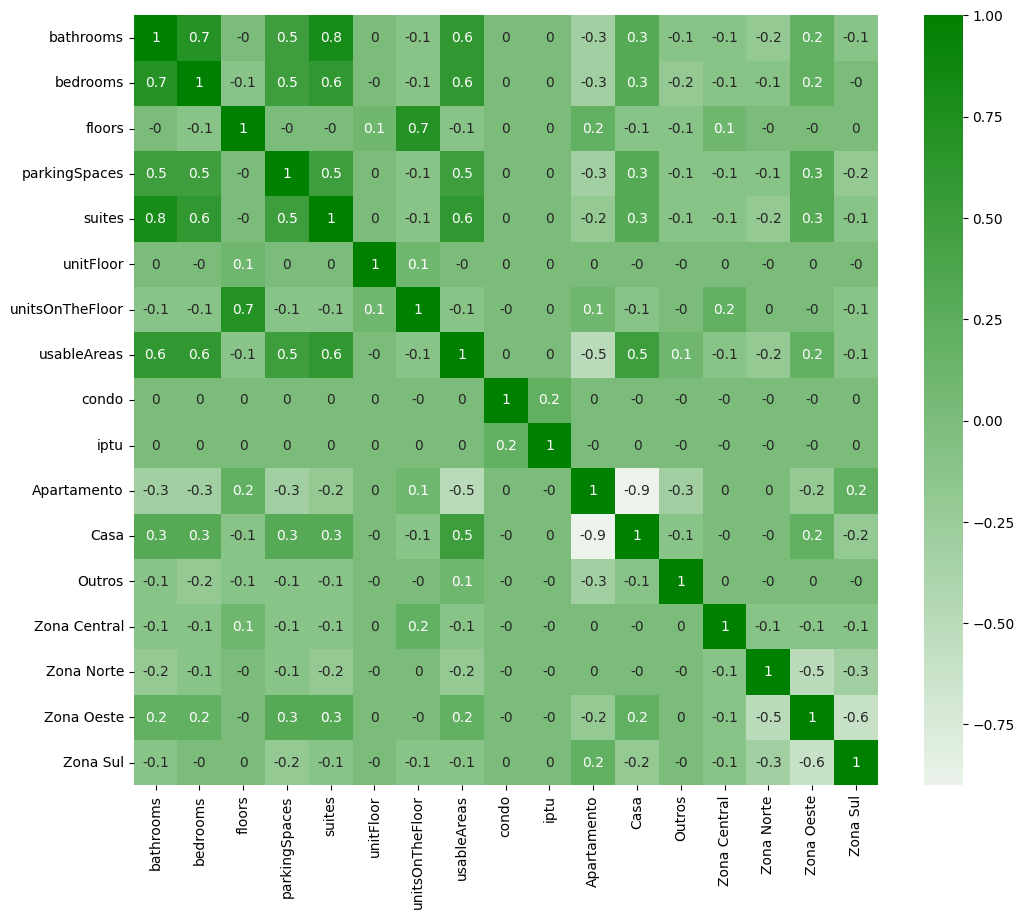

In [52]:
plt.figure(figsize = (12, 10))
paleta = sns.color_palette('light:green', as_cmap=True)
sns.heatmap(dataframe_corr.round(1), annot = True, cmap=paleta)
#

## Ajuste e Previsão

In [53]:
from pyspark.ml.regression import LinearRegression

In [54]:
treino, teste = dataset_prep.randomSplit([0.7, 0.3], seed = 101)

In [55]:
treino.count()

48528

In [56]:
teste.count()

20911

In [57]:
lr = LinearRegression()

In [58]:
modelo_lr = lr.fit(treino)

In [59]:
previsoes_lr_treino = modelo_lr.transform(treino)

In [60]:
previsoes_lr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0| 443266.0473661838|
|(17,[0,1,2,3,4,5,...|500000.0|1127455.8300442211|
|(17,[0,1,2,3,4,5,...|308615.0|  111210.499498218|
|(17,[0,1,2,3,4,5,...|279000.0| 113587.9578758899|
|(17,[0,1,2,3,4,5,...|545000.0|340703.71307723917|
|(17,[0,1,2,3,4,5,...|449000.0| 390571.9959550907|
|(17,[0,1,2,3,4,5,...|479000.0| 444003.4297175493|
|(17,[0,1,2,3,4,5,...|420000.0| 720022.1542159102|
|(17,[0,1,2,3,4,5,...|265000.0|519406.05037378933|
|(17,[0,1,2,3,4,5,...|490000.0| 845483.5388433996|
|(17,[0,1,2,3,4,5,...|650000.0| 644931.4982484158|
|(17,[0,1,2,3,4,5,...|379900.0|448889.33390194055|
|(17,[0,1,2,3,4,5,...|449000.0| 714548.9501098143|
|(17,[0,1,2,3,4,5,...|190000.0|411726.94116216776|
|(17,[0,1,2,3,4,5,...|896000.0|   597499.46015478|
|(17,[0,1,2,3,4,5,...|679000.0| 864544.0129254961|
|(17,[0,1,2,3,4,5,...|620000.0|

## Métricas

Vamos ver o R2 e RMSE - Erro quadrádico médio

In [61]:
resumo_treino = modelo_lr.summary

In [62]:
resumo_treino.r2

0.6655873678454574

In [63]:
resumo_treino.rootMeanSquaredError

810348.9695316235

In [64]:
resumo_teste = modelo_lr.evaluate(teste)

In [65]:
resumo_teste.r2

0.658520793777423

In [66]:
resumo_teste.rootMeanSquaredError

800525.9696828823

## Tabela Resumo Regressão Linear

In [67]:
print('Regressão Linear')
print('='*50)
print('Dados de treino =', 70)
print('Dados de teste =', 30)
print('='*50)
print('R2 treino=',resumo_treino.r2)
print('RMSE treino=',resumo_treino.rootMeanSquaredError)
print('='*50)
print('R2 teste=',resumo_teste.r2)
print('RMSE teste=',resumo_teste.rootMeanSquaredError)


Regressão Linear
Dados de treino = 70
Dados de teste = 30
R2 treino= 0.6655873678454574
RMSE treino= 810348.9695316235
R2 teste= 0.658520793777423
RMSE teste= 800525.9696828823


#Árvore de Decisão - Regressão

##Ajuste e Previsão

In [68]:
from pyspark.ml.regression import DecisionTreeRegressor

In [69]:
dtr = DecisionTreeRegressor(seed = 101, maxDepth=7)

In [70]:
modelo_dtr = dtr.fit(treino)

In [71]:
previsoes_dtr_treino = modelo_dtr.transform(treino)

In [72]:
previsoes_dtr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|500000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|308615.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|279000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|545000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|479000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|420000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|265000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|490000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...|650000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...|379900.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|449000.0|     445137.460625|
|(17,[0,1,2,3,4,5,...|190000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|896000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...|679000.0|1158420.7653661144|
|(17,[0,1,2,3,4,5,...|620000.0|

##Métricas

In [73]:
from pyspark.ml.evaluation import RegressionEvaluator

In [74]:
evaluator = RegressionEvaluator()
print(evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: 'rmse'}))

0.7930752588471226
637436.5434260432


In [75]:
previsoes_dtr_teste = modelo_dtr.transform(teste)
previsoes_dtr_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 350000.0|  820272.937751004|
|(17,[0,1,2,3,4,5,...| 340000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 430000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 600000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 439000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 333000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 948000.0|  736254.943802521|
|(17,[0,1,2,3,4,5,...| 459600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 447600.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 360000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...| 407000.0| 553816.2525860447|
|(17,[0,1,2,3,4,5,...| 310000.0| 340855.8044843049|
|(17,[0,1,2,3,4,5,...|1400000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1180000.0|1289301.4891122277|
|(17,[0,1,2,3,4,5,...|1299500.0|1158420.7653661144|
|(17,[0,1,2,

In [76]:
print(evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'rmse'}))

0.7738133838892687
651518.489920883


## Tabela Resumo Árvore de Decisões

In [77]:
print('Decision Tree Regression')
print('='*50)
print('R2 treino=',evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: 'r2'}))
print('RMSE treino=',evaluator.evaluate(previsoes_dtr_treino, {evaluator.metricName: 'rmse'}))
print('='*50)
print('R2 teste=',evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'rmse'}))

Decision Tree Regression
R2 treino= 0.7930752588471226
RMSE treino= 637436.5434260432
R2 teste= 0.7738133838892687
RMSE teste= 651518.489920883


#Random Forest

##Ajuste e Previsão

In [78]:
from pyspark.ml.regression import RandomForestRegressor

In [79]:
rfr = RandomForestRegressor(seed = 101, maxDepth=7, numTrees=10)

In [80]:
modelo_rfr = rfr.fit(treino)

In [81]:
previsoes_rfr_treino = modelo_rfr.transform(treino)

In [82]:
previsoes_rfr_treino.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|260000.0|390218.33742322924|
|(17,[0,1,2,3,4,5,...|500000.0| 510060.6595782173|
|(17,[0,1,2,3,4,5,...|308615.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|279000.0|360766.74127901345|
|(17,[0,1,2,3,4,5,...|545000.0|  396904.928725379|
|(17,[0,1,2,3,4,5,...|449000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...|479000.0|433807.13396085694|
|(17,[0,1,2,3,4,5,...|420000.0| 664440.4325776277|
|(17,[0,1,2,3,4,5,...|265000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...|490000.0| 816123.0337632223|
|(17,[0,1,2,3,4,5,...|650000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...|379900.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|449000.0|403131.21721626434|
|(17,[0,1,2,3,4,5,...|190000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...|896000.0| 547828.3209496561|
|(17,[0,1,2,3,4,5,...|679000.0| 893791.6624292185|
|(17,[0,1,2,3,4,5,...|620000.0|

##Métricas

In [83]:
print(evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: 'rmse'}))

0.8017561510914318
623922.4426224458


In [84]:
previsoes_rfr_teste = modelo_rfr.transform(teste)
previsoes_rfr_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 350678.0454640939|
|(17,[0,1,2,3,4,5,...| 350000.0| 792518.9735011571|
|(17,[0,1,2,3,4,5,...| 340000.0|479615.50733929937|
|(17,[0,1,2,3,4,5,...| 430000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 600000.0| 526635.5362588142|
|(17,[0,1,2,3,4,5,...| 439000.0| 550795.8732599718|
|(17,[0,1,2,3,4,5,...| 333000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 948000.0| 640247.1517314625|
|(17,[0,1,2,3,4,5,...| 459600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 447600.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 360000.0| 356904.3339549792|
|(17,[0,1,2,3,4,5,...| 407000.0|  492913.652312712|
|(17,[0,1,2,3,4,5,...| 310000.0|412580.35636663495|
|(17,[0,1,2,3,4,5,...|1400000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1180000.0| 1375418.570408164|
|(17,[0,1,2,3,4,5,...|1299500.0|1111896.8209940076|
|(17,[0,1,2,

In [113]:
print(evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'r2'}))
print(evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'rmse'}))

0.7905295233620376
626981.4677383784


##Tabela de Resumo Random Forest

In [116]:
print('Random Forest Regression')
print('='*50)
print('R2 treino=',evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: 'r2'}))
print('RMSE treino=',evaluator.evaluate(previsoes_rfr_treino, {evaluator.metricName: 'rmse'}))
print('='*50)
print('R2 teste=',evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'rmse'}))

Random Forest Regression
R2 treino= 0.8017561510914318
RMSE treino= 623922.4426224458
R2 teste= 0.7905295233620376
RMSE teste= 626981.4677383784


In [131]:
print(5)

5


# Otimizando os modelos

## Cross Validation para Decision Tree

In [132]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [133]:
dtr = DecisionTreeRegressor()

configurando o grid com o cross validation

In [134]:
grid = ParamGridBuilder()\
.addGrid(dtr.maxDepth, [2, 5, 10,])\
.addGrid(dtr.maxBins, [10, 32, 45])\
.build()

In [135]:
evaluator = RegressionEvaluator()

configurando o modelo com o Cross validation

In [136]:
dtr_cv = CrossValidator(
    estimator = dtr,
    estimatorParamMaps = grid,
    evaluator = evaluator,
    numFolds=3,
    seed = 101)

treinando

In [137]:
modelo_dtr_cv = dtr_cv.fit(treino)

In [138]:
previsoes_dtr_cv_teste = modelo_dtr_cv.transform(teste)
previsoes_dtr_cv_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...| 350000.0| 893428.5392156863|
|(17,[0,1,2,3,4,5,...| 340000.0|511038.20238095237|
|(17,[0,1,2,3,4,5,...| 430000.0| 673711.5416997618|
|(17,[0,1,2,3,4,5,...| 600000.0| 673711.5416997618|
|(17,[0,1,2,3,4,5,...| 439000.0|511038.20238095237|
|(17,[0,1,2,3,4,5,...| 333000.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...| 948000.0| 788775.1784615385|
|(17,[0,1,2,3,4,5,...| 459600.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...| 447600.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...| 360000.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...| 407000.0|511038.20238095237|
|(17,[0,1,2,3,4,5,...| 310000.0| 332384.5158946412|
|(17,[0,1,2,3,4,5,...|1400000.0|1988287.6627906978|
|(17,[0,1,2,3,4,5,...|1180000.0|1988287.6627906978|
|(17,[0,1,2,3,4,5,...|1299500.0|1383387.9560878244|
|(17,[0,1,2,

In [141]:
print('Decision Tree Regression with Cross Validation')
print('='*50)
print('Com Cross Validation')
print('R2 teste=',evaluator.evaluate(previsoes_dtr_cv_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(previsoes_dtr_cv_teste, {evaluator.metricName: 'rmse'}))
print('='*50)
print('Sem Cross Validation')
print('R2 teste=',evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(previsoes_dtr_teste, {evaluator.metricName: 'rmse'}))

Decision Tree Regression with Cross Validation
Com Cross Validation
R2 teste= 0.7906667403473269
RMSE teste= 626776.0769786034
Sem Cross Validation
R2 teste= 0.7738133838892687
RMSE teste= 651518.489920883


## Cross Validation para Random Forest

In [143]:
rfr = RandomForestRegressor()

In [144]:
grid = ParamGridBuilder()\
.addGrid(rfr.numTrees, [10, 20, 30])\
.addGrid(rfr.maxDepth, [5, 10])\
.addGrid(rfr.maxBins, [10, 32, 45])\
.build()

In [145]:
rfr_cv = CrossValidator(
    estimator = rfr,
    estimatorParamMaps = grid,
    evaluator = evaluator,
    numFolds=3)

In [146]:
modelo_rfr_cv = rfr_cv.fit(treino)

In [147]:
provisoes_rfr_cv_teste = modelo_rfr_cv.transform(teste)
provisoes_rfr_cv_teste.show()

+--------------------+---------+------------------+
|            features|    label|        prediction|
+--------------------+---------+------------------+
|(17,[0,1,2,3,4,5,...| 199000.0|330595.78048388095|
|(17,[0,1,2,3,4,5,...| 350000.0| 789672.0852400765|
|(17,[0,1,2,3,4,5,...| 340000.0| 536850.7631717811|
|(17,[0,1,2,3,4,5,...| 430000.0| 616777.2793089832|
|(17,[0,1,2,3,4,5,...| 600000.0| 644019.0970355689|
|(17,[0,1,2,3,4,5,...| 439000.0| 503082.9467294915|
|(17,[0,1,2,3,4,5,...| 333000.0| 361233.6796923205|
|(17,[0,1,2,3,4,5,...| 948000.0| 664781.3635282823|
|(17,[0,1,2,3,4,5,...| 459600.0| 363602.1847997177|
|(17,[0,1,2,3,4,5,...| 447600.0| 363602.1847997177|
|(17,[0,1,2,3,4,5,...| 360000.0| 363602.1847997177|
|(17,[0,1,2,3,4,5,...| 407000.0|520006.91862695746|
|(17,[0,1,2,3,4,5,...| 310000.0| 381185.8232504053|
|(17,[0,1,2,3,4,5,...|1400000.0|1329474.2430177457|
|(17,[0,1,2,3,4,5,...|1180000.0|1359795.4249225077|
|(17,[0,1,2,3,4,5,...|1299500.0|1270474.5219717226|
|(17,[0,1,2,

In [149]:
print('Random Forest Regression with Cross Validation')
print('='*50)
print('Com Cross Validation')
print('R2 teste=',evaluator.evaluate(provisoes_rfr_cv_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(provisoes_rfr_cv_teste, {evaluator.metricName: 'rmse'}))
print('='*50)
print('Sem Cross Validation')
print('R2 teste=',evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'r2'}))
print('RMSE teste=',evaluator.evaluate(previsoes_rfr_teste, {evaluator.metricName: 'rmse'}))

Random Forest Regression with Cross Validation
Com Cross Validation
R2 teste= 0.8303197192707168
RMSE teste= 564298.6103072849
Sem Cross Validation
R2 teste= 0.7905295233620376
RMSE teste= 626981.4677383784


## Prevendo valores

In [150]:
X

['bathrooms',
 'bedrooms',
 'floors',
 'parkingSpaces',
 'suites',
 'unitFloor',
 'unitsOnTheFloor',
 'usableAreas',
 'condo',
 'iptu',
 'Apartamento',
 'Casa',
 'Outros',
 'Zona Central',
 'Zona Norte',
 'Zona Oeste',
 'Zona Sul']

In [176]:
novo_imovel = [{
    'bathrooms': 2,
    'bedrooms': 2,
    'floors': 1,
    'parkingSpaces': 1,
    'suites': 1,
    'unitFloor': 15,
    'unitsOnTheFloor': 15,
    'usableAreas': 70,
    'condo': 900,
    'iptu': 120,
    'Apartamento': 1,
    'Casa': 0,
    'Outros': 0,
    'Zona Central': 1,
    'Zona Norte': 0,
    'Zona Oeste': 0,
    'Zona Sul': 0,
    'label': 0

}]

In [177]:
meu_imovel = spark.createDataFrame(novo_imovel)

In [178]:
meu_imovel.show()

+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+
|Apartamento|Casa|Outros|Zona Central|Zona Norte|Zona Oeste|Zona Sul|bathrooms|bedrooms|condo|floors|iptu|label|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|
+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+
|          1|   0|     0|           1|         0|         0|       0|        2|       2|  900|     1| 120|    0|            1|     1|       15|             15|         70|
+-----------+----+------+------------+----------+----------+--------+---------+--------+-----+------+----+-----+-------------+------+---------+---------------+-----------+



vetorizando os dados novos

In [179]:
assembler = VectorAssembler(inputCols = X, outputCol = 'features')

In [180]:
meu_imovel_vetorizado = assembler.transform(meu_imovel).select('features', 'label')

In [181]:
meu_imovel_vetorizado.show()

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[2.0,2.0,1.0,1.0,...|    0|
+--------------------+-----+



usando o melhor modelo para prever o preço do ímovel

In [182]:
modelo_rfr_cv.transform(meu_imovel_vetorizado).show()

+--------------------+-----+-----------------+
|            features|label|       prediction|
+--------------------+-----+-----------------+
|[2.0,2.0,1.0,1.0,...|    0|589451.7117092345|
+--------------------+-----+-----------------+

